In [29]:
# STEP 1: Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# For splitting
from sklearn.model_selection import train_test_split

# For scaling
from sklearn.preprocessing import StandardScaler

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [31]:
# STEP 2: EDA (Exploratory Data Analysis)

# Load dataset
df = pd.read_csv("loan_data.csv")

# First 5 rows
df.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [33]:
# Basic info about dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [35]:
# Summary statistics
df.describe()


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [37]:
# Shape of dataset
df.shape


(45000, 14)

In [39]:
# Check missing values
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

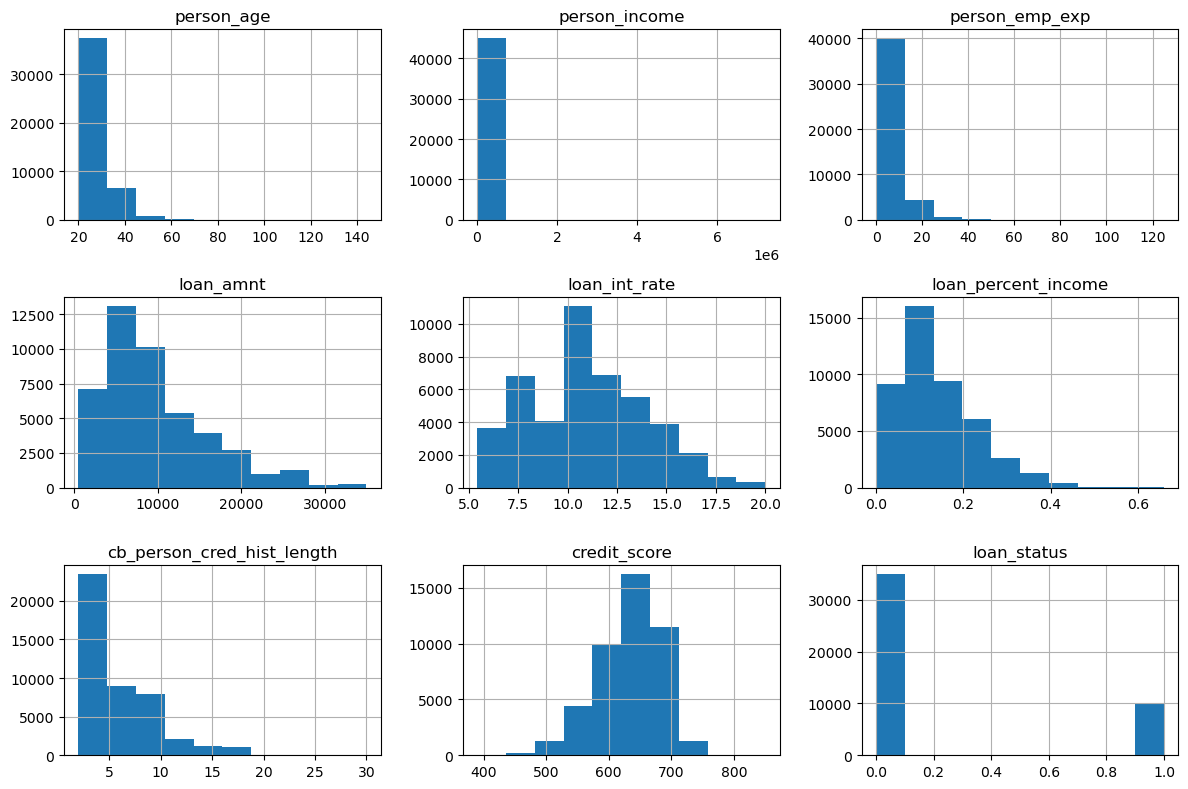

In [41]:
# Histograms for numerical features
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()


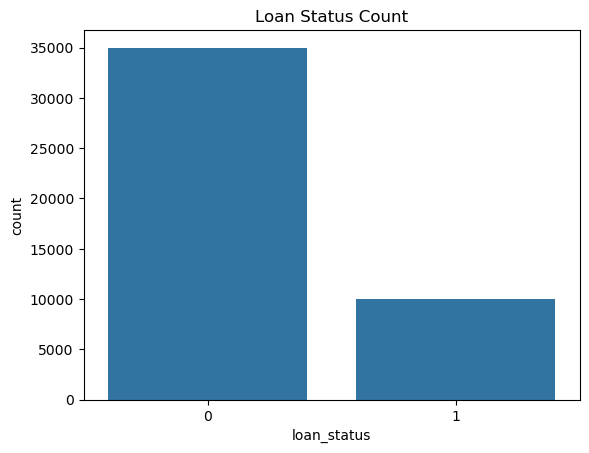

In [42]:
# Countplot for loan_status
sns.countplot(data=df, x="loan_status")
plt.title("Loan Status Count")
plt.show()

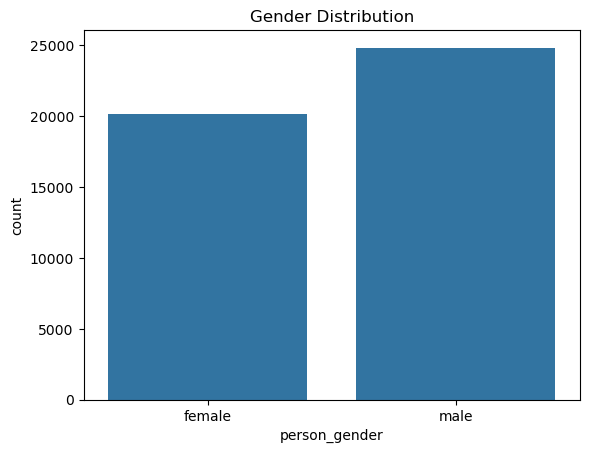

In [43]:
sns.countplot(data=df, x="person_gender")
plt.title("Gender Distribution")
plt.show()

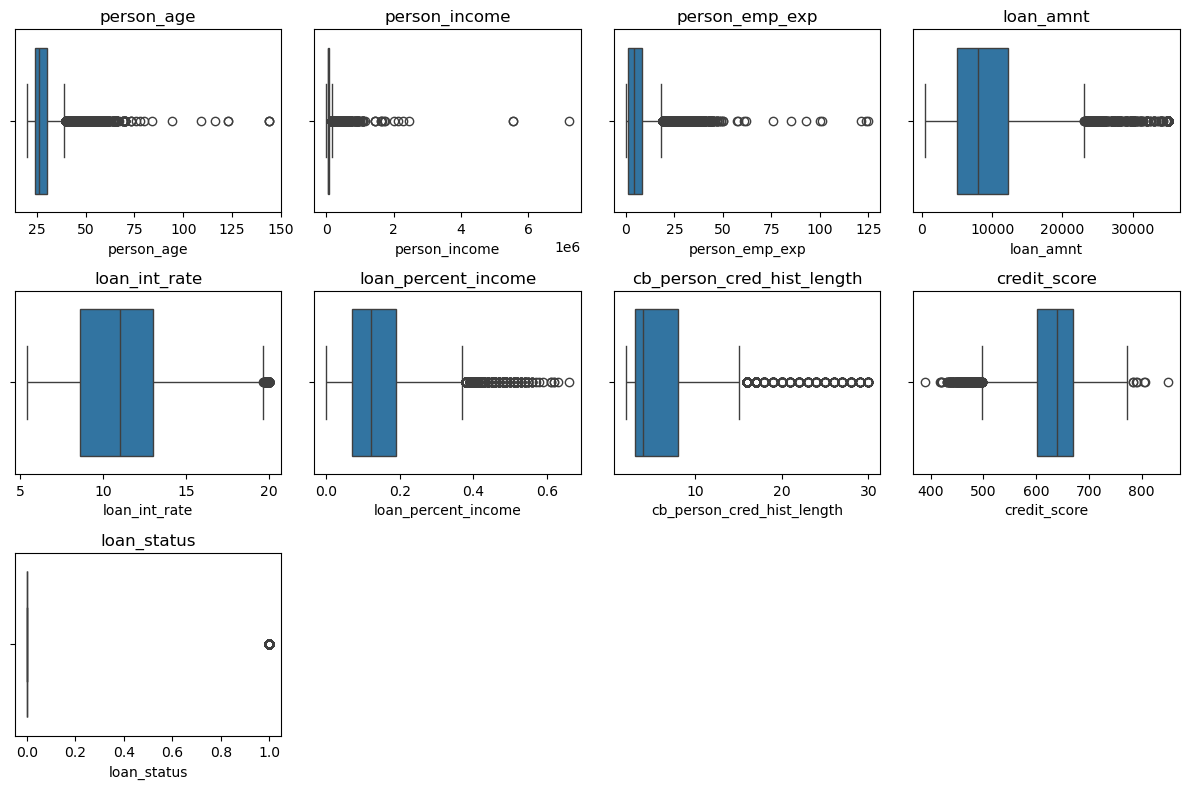

In [46]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


In [48]:
# Detecting outliers using IQR method

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    
    print(f"{col}: {len(outliers)} outliers")


person_age: 2188 outliers
person_income: 2218 outliers
person_emp_exp: 1724 outliers
loan_amnt: 2348 outliers
loan_int_rate: 124 outliers
loan_percent_income: 744 outliers
cb_person_cred_hist_length: 1366 outliers
credit_score: 467 outliers
loan_status: 10000 outliers


In [49]:
from sklearn.preprocessing import StandardScaler

# Selecting only numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,-0.953538,female,Master,-0.104090,-0.892284,RENT,4.024953,PERSONAL,1.683039,4.016394,-0.739109,-1.419814,No,1.870829
1,-1.118963,female,High School,-0.846005,-0.892284,OWN,-1.359209,EDUCATION,0.044782,-0.684829,-0.996863,-2.549975,Yes,-0.534522
2,-0.457264,female,High School,-0.844065,-0.397517,MORTGAGE,-0.646600,MEDICAL,0.625557,3.443074,-0.739109,0.047412,No,1.870829
3,-0.788113,female,Bachelor,-0.007039,-0.892284,RENT,4.024953,MEDICAL,1.417829,3.443074,-0.996863,0.840507,No,1.870829
4,-0.622689,male,Master,-0.176371,-0.727362,RENT,4.024953,MEDICAL,1.095549,4.475050,-0.481354,-0.924130,No,1.870829


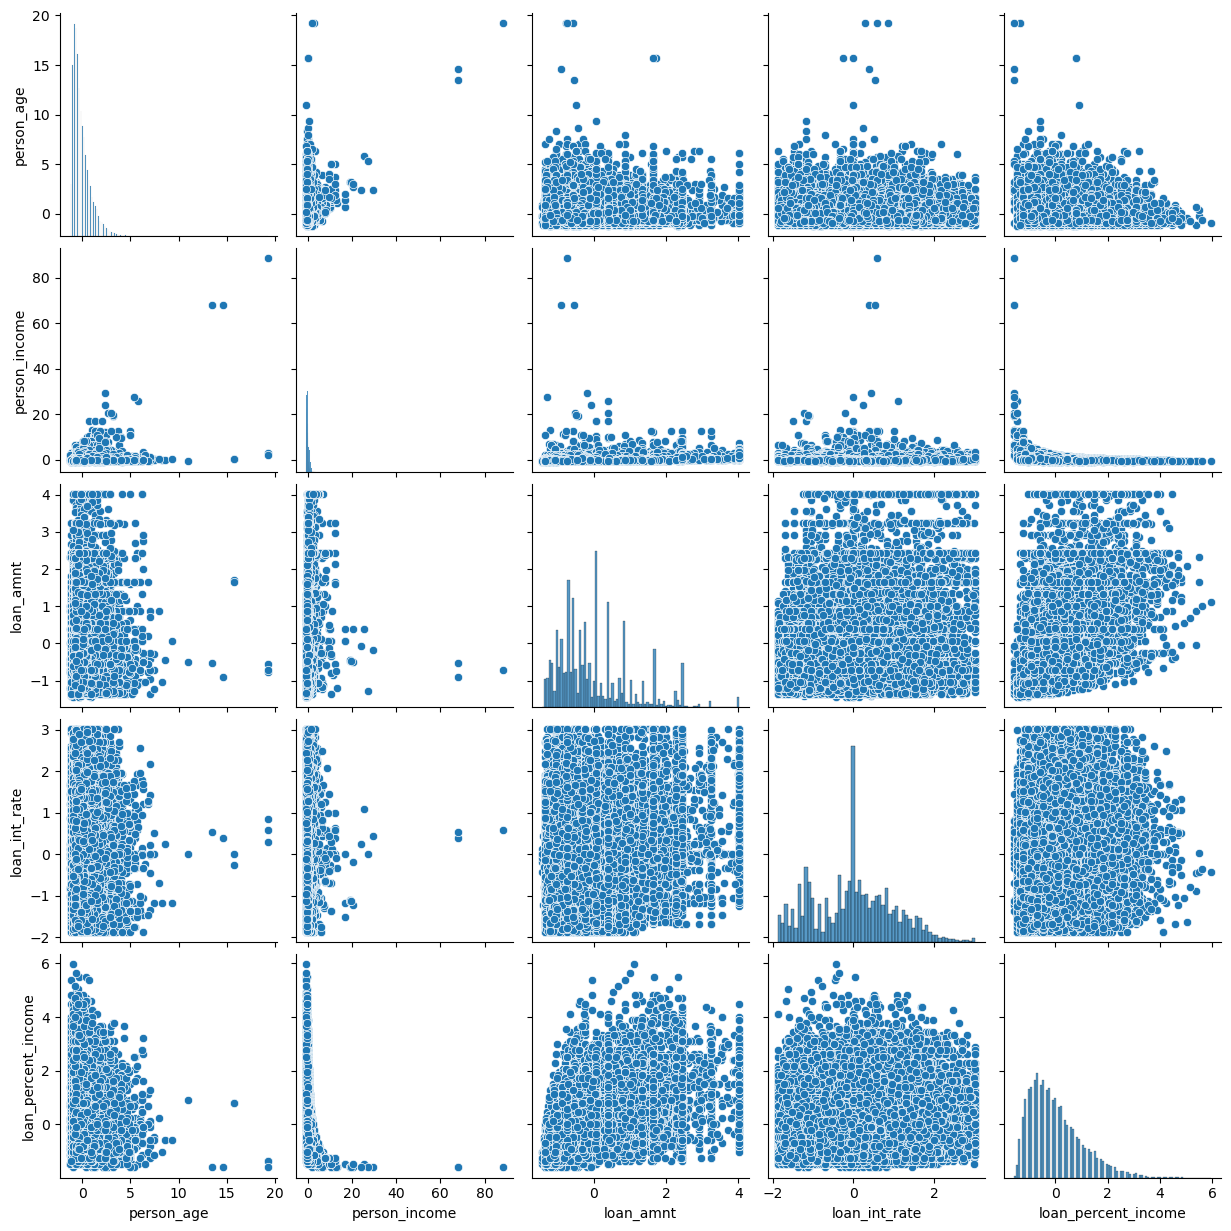

In [50]:
# Selecting a few important columns for pair plot
selected_cols = ["person_age", "person_income", "loan_amnt", "loan_int_rate", "loan_percent_income"]

sns.pairplot(df[selected_cols])
plt.show()


In [56]:
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()
corr_matrix


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
person_age,1.000000,0.193698,0.954412,0.050750,0.013402,-0.043299,0.861985,0.178432,-0.021476
person_income,0.193698,1.000000,0.185987,0.242290,0.001510,-0.234177,0.124316,0.035919,-0.135808
person_emp_exp,0.954412,0.185987,1.000000,0.044589,0.016631,-0.039862,0.824272,0.186196,-0.020481
loan_amnt,0.050750,0.242290,0.044589,1.000000,0.146093,0.593011,0.042969,0.009074,0.107714
loan_int_rate,0.013402,0.001510,0.016631,0.146093,1.000000,0.125209,0.018008,0.011498,0.332005
loan_percent_income,-0.043299,-0.234177,-0.039862,0.593011,0.125209,1.000000,-0.031868,-0.011483,0.384880
cb_person_cred_hist_length,0.861985,0.124316,0.824272,0.042969,0.018008,-0.031868,1.000000,0.155204,-0.014851
credit_score,0.178432,0.035919,0.186196,0.009074,0.011498,-0.011483,0.155204,1.000000,-0.007647
loan_status,-0.021476,-0.135808,-0.020481,0.107714,0.332005,0.384880,-0.014851,-0.007647,1.000000


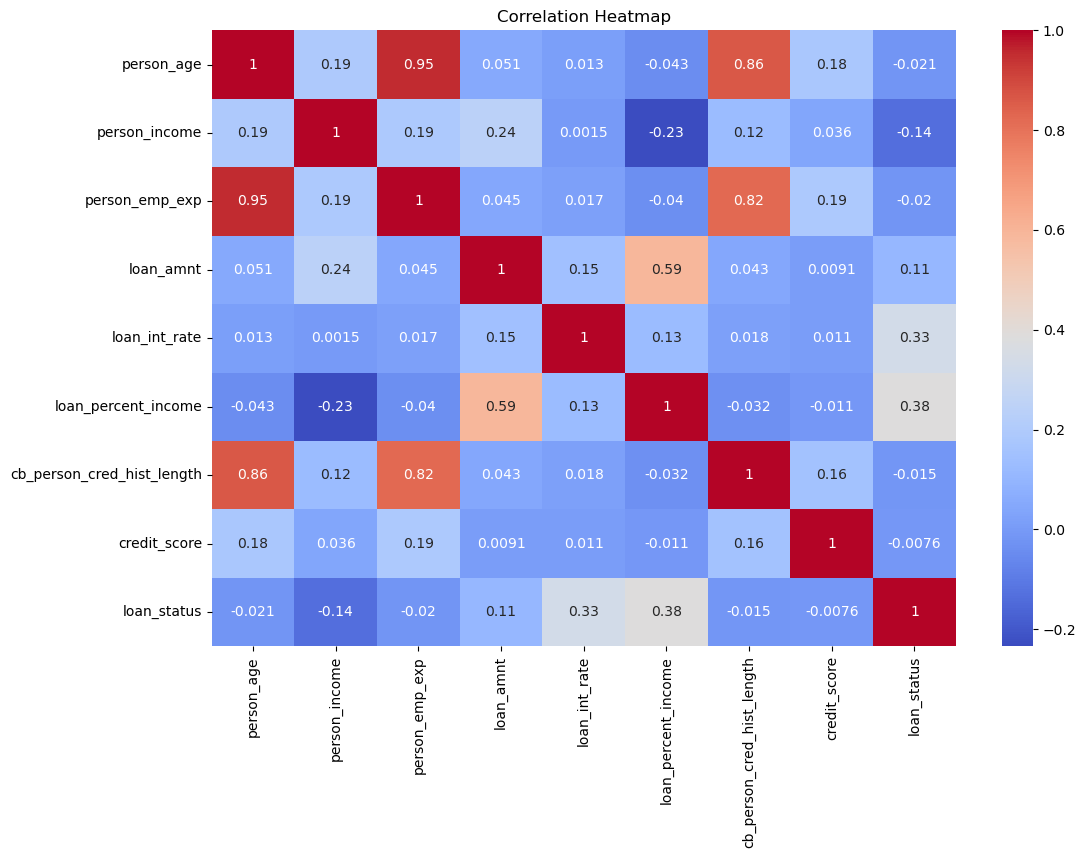

In [58]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [60]:
df = df.drop(["person_gender", "person_home_ownership"], axis=1)
df.head()

,person_age,person_education,person_income,person_emp_exp,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,-0.953538,Master,-0.104090,-0.892284,4.024953,PERSONAL,1.683039,4.016394,-0.739109,-1.419814,No,1.870829
1,-1.118963,High School,-0.846005,-0.892284,-1.359209,EDUCATION,0.044782,-0.684829,-0.996863,-2.549975,Yes,-0.534522
2,-0.457264,High School,-0.844065,-0.397517,-0.646600,MEDICAL,0.625557,3.443074,-0.739109,0.047412,No,1.870829
3,-0.788113,Bachelor,-0.007039,-0.892284,4.024953,MEDICAL,1.417829,3.443074,-0.996863,0.840507,No,1.870829
4,-0.622689,Master,-0.176371,-0.727362,4.024953,MEDICAL,1.095549,4.475050,-0.481354,-0.924130,No,1.870829


In [78]:
original = pd.read_csv("loan_data.csv")
df["loan_status"] = original["loan_status"]

In [80]:
df["loan_status"].unique()


array([1, 0], dtype=int64)

In [82]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]


In [84]:
X = pd.get_dummies(X, drop_first=True)


In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [88]:
log_reg = LogisticRegression()
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()

In [90]:
# Training all models

log_reg.fit(X_train, y_train)
knn.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

print("Training completed.")

Training completed.


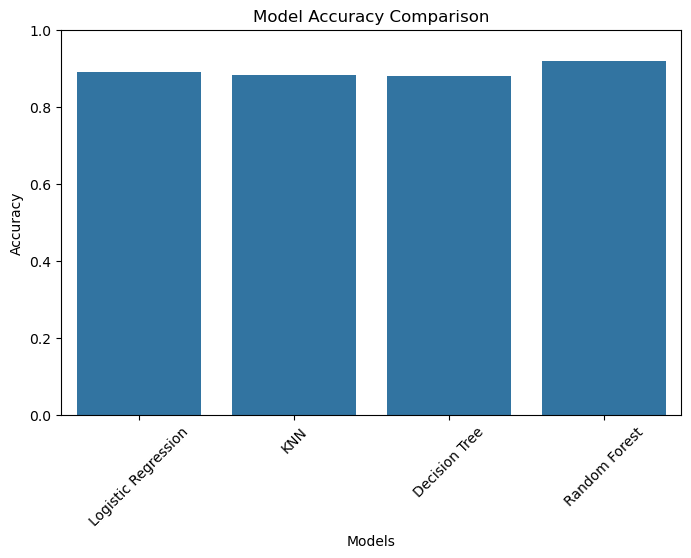

In [100]:
# Accuracy bar plot for all models

model_names = []
accuracies = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    model_names.append(name)
    accuracies.append(acc)

plt.figure(figsize=(8,5))
sns.barplot(x=model_names, y=accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()


In [92]:
# Comparing model accuracies

models = {
    "Logistic Regression": log_reg,
    "KNN": knn,
    "Decision Tree": dt,
    "Random Forest": rf
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])

# Creating a comparison DataFrame
comparison_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
comparison_df


,Model,Accuracy
0,Logistic Regression,0.889333
1,KNN,0.881333
2,Decision Tree,0.880778
3,Random Forest,0.917556


In [94]:
y_pred = rf.predict(X_test)


In [96]:
cm = confusion_matrix(y_test, y_pred)
cm


array([[6700,  290],
       [ 452, 1558]], dtype=int64)

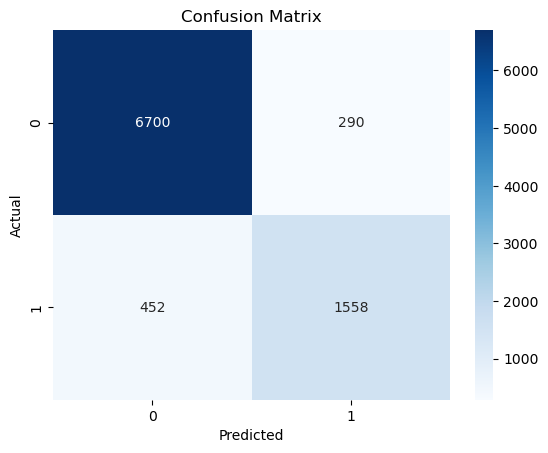

In [98]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()